### Batchsize Scaling
**What it does:**
This notebook demonstrates how sample-wise gradient metrics scale with batch size by computing metrics on identical repeated samples across different batch sizes (8 to 64).

**Scaling behavior:**
Network gradients scale linearly with batch size (unnormalized), because they're summed across all samples in the batch. Loss gradients scale inversely (1/N) with batch size due to the reduction="mean" in the loss function, but when normalized, both metrics become batch-size invariant.

In [16]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import display

from perspic.calculator.samplewise_functorch import SamplewiseCalculatorFunctorch

torch.set_float32_matmul_precision('high')

In [17]:
class MLP(nn.Module):
    """Simple MLP for demonstration.

    """
    def __init__(self, input_dim=10, hidden_dim=20, output_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [18]:
def analyze_batch_size_scaling():
    """Analyze how metrics scale with batch size using repeated samples.

    By repeating identical samples, we can isolate the effect of batch size
    on the computed metrics, independent of sample variance.
    """
    torch.manual_seed(42)

    # Base batch size and multipliers to test
    base_batch_size = 8
    multipliers = [1, 2, 3, 4, 5, 6, 7, 8]
    batch_sizes = [base_batch_size * m for m in multipliers]

    # Create base data that will be repeated
    X_base = torch.randn(base_batch_size, 10)
    y_base = torch.randint(0, 2, (base_batch_size,))

    model = MLP()
    # Key: use reduction="mean" for proper batch-size invariance
    loss_fn = nn.CrossEntropyLoss(reduction="mean")
    calculator = SamplewiseCalculatorFunctorch()

    # Storage for results
    results = {
        "batch_sizes": batch_sizes,
        "multipliers": multipliers,
        "network_normalized": [],
        "network_unnormalized": [],
        "loss_normalized": [],
        "loss_unnormalized": [],
    }

    print("Computing metrics for different batch sizes...")
    print(f"Base batch size: {base_batch_size}")
    print(f"Testing batch sizes: {batch_sizes}\n")

    for multiplier in multipliers:
        # Create repeated data (same samples repeated N times)
        X_repeated = X_base.repeat(multiplier, 1)
        y_repeated = y_base.repeat(multiplier)

        # Compute normalized metrics
        res_norm = calculator.compute(
            model, loss_fn, X_repeated, y_repeated, normalize=True
        )
        results["network_normalized"].append(
            res_norm["batch_grad_norms_network"].detach().item()
        )
        results["loss_normalized"].append(
            res_norm["batch_grad_norms_loss"].detach().item()
        )

        # Compute unnormalized metrics
        res_unnorm = calculator.compute(
            model, loss_fn, X_repeated, y_repeated, normalize=False
        )
        results["network_unnormalized"].append(
            res_unnorm["batch_grad_norms_network"].detach().item()
        )
        results["loss_unnormalized"].append(
            res_unnorm["batch_grad_norms_loss"].detach().item()
        )

    return results

In [19]:
def plot_scaling_behavior(results):
    """Generate comprehensive plots showing correct scaling behavior.
    """
    batch_sizes = np.array(results["batch_sizes"])
    multipliers = np.array(results["multipliers"])

    # Convert to numpy arrays
    network_norm = np.array(results["network_normalized"])
    network_unnorm = np.array(results["network_unnormalized"])
    loss_norm = np.array(results["loss_normalized"])
    loss_unnorm = np.array(results["loss_unnormalized"])

    # Create figure with 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Batch-Size Scaling of Sample-wise Gradient Metrics\n"
        "(Using repeated identical samples with CrossEntropyLoss(reduction='mean'))",
        fontsize=14,
        fontweight="bold",
    )

    # Colors
    color_actual = "#2E86AB"
    color_reference = "#E94F37"
    color_ideal = "#28A745"

    # --- Plot 1: Unnormalized Network Gradient Norms ---
    ax1 = axes[0, 0]
    expected_linear = network_unnorm[0] * multipliers

    ax1.plot(
        batch_sizes, network_unnorm, "o-", color=color_actual, 
        linewidth=2, markersize=8, label="Actual"
    )
    ax1.plot(
        batch_sizes, expected_linear, "--", color=color_reference, 
        linewidth=2, label="Expected (linear)"
    )
    ax1.set_xlabel("Batch Size", fontsize=11)
    ax1.set_ylabel("Gradient Norm", fontsize=11)
    ax1.set_title("Unnormalized Network Gradient Norms\n(Scales linearly with batch size ✓)", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(batch_sizes)

    # --- Plot 2: Unnormalized Loss Gradient Norms ---
    ax2 = axes[0, 1]
    # With reduction="mean", loss gradient norms scale inversely (1/N)
    expected_inverse = loss_unnorm[0] / multipliers

    ax2.plot(
        batch_sizes, loss_unnorm, "o-", color=color_actual, 
        linewidth=2, markersize=8, label="Actual"
    )
    ax2.plot(
        batch_sizes, expected_inverse, "--", color=color_reference, 
        linewidth=2, label="Expected (1/N scaling)"
    )
    ax2.set_xlabel("Batch Size", fontsize=11)
    ax2.set_ylabel("Gradient Norm", fontsize=11)
    ax2.set_title("Unnormalized Loss Gradient Norms\n(Scales as 1/N due to reduction='mean' ✓)", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(batch_sizes)

    # --- Plot 3: Normalized Network Gradient Norms ---
    ax3 = axes[1, 0]
    ideal_constant_net = np.full_like(network_norm, network_norm[0])

    ax3.plot(
        batch_sizes, network_norm, "o-", color=color_actual, 
        linewidth=2, markersize=8, label="Actual"
    )
    ax3.plot(
        batch_sizes, ideal_constant_net, "--", color=color_ideal, 
        linewidth=2, label="Expected (constant)"
    )
    ax3.set_xlabel("Batch Size", fontsize=11)
    ax3.set_ylabel("Gradient Norm", fontsize=11)
    ax3.set_title("Normalized Network Gradient Norms\n(Batch-size invariant ✓)", fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xticks(batch_sizes)
    # Show small variations
    y_margin = network_norm[0] * 0.1
    ax3.set_ylim(network_norm[0] - y_margin, network_norm[0] + y_margin)

    # --- Plot 4: Normalized Loss Gradient Norms ---
    ax4 = axes[1, 1]
    ideal_constant_loss = np.full_like(loss_norm, loss_norm[0])

    ax4.plot(
        batch_sizes, loss_norm, "o-", color=color_actual, 
        linewidth=2, markersize=8, label="Actual"
    )
    ax4.plot(
        batch_sizes, ideal_constant_loss, "--", color=color_ideal, 
        linewidth=2, label="Expected (constant)"
    )
    ax4.set_xlabel("Batch Size", fontsize=11)
    ax4.set_ylabel("Gradient Norm", fontsize=11)
    ax4.set_title("Normalized Loss Gradient Norms\n(Batch-size invariant ✓)", fontsize=12)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_xticks(batch_sizes)
    # Show small variations
    y_margin = loss_norm[0] * 0.1
    ax4.set_ylim(loss_norm[0] - y_margin, loss_norm[0] + y_margin)

    plt.tight_layout()
    return fig

In [20]:
def plot_scaling_ratios(results):
    """Plot scaling ratios to verify exact scaling behavior.
    """
    multipliers = np.array(results["multipliers"])

    # Compute ratios relative to base batch
    network_norm = np.array(results["network_normalized"])
    network_unnorm = np.array(results["network_unnormalized"])
    loss_norm = np.array(results["loss_normalized"])
    loss_unnorm = np.array(results["loss_unnormalized"])

    network_norm_ratio = network_norm / network_norm[0]
    network_unnorm_ratio = network_unnorm / network_unnorm[0]
    loss_norm_ratio = loss_norm / loss_norm[0]
    loss_unnorm_ratio = loss_unnorm / loss_unnorm[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Batch Size Scaling Analysis\n"
        "(Metric Value / Base Value vs Batch Size Multiplier)",
        fontsize=14,
        fontweight="bold",
    )

    # Colors for better distinction
    color_unnorm = "#2E86AB"  # Blue
    color_norm = "#E94F37"    # Red
    color_linear = "#888888"  # Gray
    color_constant = "#28A745"  # Green

    # --- Network metrics ---
    ax1 = axes[0]
    ax1.plot(
        multipliers, network_unnorm_ratio, "o-", color=color_unnorm,
        linewidth=2, markersize=8, label="Unnormalized"
    )
    ax1.plot(
        multipliers, network_norm_ratio, "s-", color=color_norm,
        linewidth=2, markersize=8, label="Normalized"
    )
    ax1.plot(
        multipliers, multipliers, "--", color=color_linear, 
        linewidth=2, label="Linear (y=x)"
    )
    ax1.plot(
        multipliers, np.ones_like(multipliers), ":", 
        color=color_constant, linewidth=2, label="Constant (y=1)"
    )
    ax1.set_xlabel("Batch Size Multiplier", fontsize=11)
    ax1.set_ylabel("Metric Ratio", fontsize=11)
    ax1.set_title("Network Gradient Norms\nUnnormalized: linear | Normalized: constant", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Loss metrics ---
    ax2 = axes[1]
    ax2.plot(
        multipliers, loss_unnorm_ratio, "o-", color=color_unnorm,
        linewidth=2, markersize=8, label="Unnormalized"
    )
    ax2.plot(
        multipliers, loss_norm_ratio, "s-", color=color_norm,
        linewidth=2, markersize=8, label="Normalized"
    )
    ax2.plot(
        multipliers, 1 / multipliers, "--", color=color_linear, 
        linewidth=2, label="Inverse (y=1/x)"
    )
    ax2.plot(
        multipliers, np.ones_like(multipliers), ":", 
        color=color_constant, linewidth=2, label="Constant (y=1)"
    )
    ax2.set_xlabel("Batch Size Multiplier", fontsize=11)
    ax2.set_ylabel("Metric Ratio", fontsize=11)
    ax2.set_title("Loss Gradient Norms\nUnnormalized: inverse | Normalized: constant", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

In [21]:
def print_summary(results):
    """Print a summary table of the results."""
    batch_sizes = results["batch_sizes"]
    multipliers = results["multipliers"]
    
    network_norm = np.array(results["network_normalized"])
    network_unnorm = np.array(results["network_unnormalized"])
    loss_norm = np.array(results["loss_normalized"])
    loss_unnorm = np.array(results["loss_unnormalized"])
    
    print("=" * 90)
    print("BATCH-SIZE SCALING ANALYSIS RESULTS")
    print("=" * 90)
    
    print("\n" + "-" * 90)
    print("RAW VALUES")
    print("-" * 90)
    header = f"{'Batch':<8} {'Mult':<6} {'Net Unnorm':<14} {'Net Norm':<14} {'Loss Unnorm':<14} {'Loss Norm':<14}"
    print(header)
    print("-" * 90)
    for i, (bs, m) in enumerate(zip(batch_sizes, multipliers)):
        print(
            f"{bs:<8} {m:<6} {network_unnorm[i]:<14.4f} {network_norm[i]:<14.4f} "
            f"{loss_unnorm[i]:<14.4f} {loss_norm[i]:<14.4f}"
        )
    
    print("\n" + "-" * 90)
    print("SCALING RATIOS (relative to base batch)")
    print("-" * 90)
    header = f"{'Mult':<8} {'Net Unnorm':<14} {'Net Norm':<14} {'Loss Unnorm':<14} {'Loss Norm':<14}"
    print(header)
    print("-" * 90)
    for i, m in enumerate(multipliers):
        net_unnorm_ratio = network_unnorm[i] / network_unnorm[0]
        net_norm_ratio = network_norm[i] / network_norm[0]
        loss_unnorm_ratio = loss_unnorm[i] / loss_unnorm[0]
        loss_norm_ratio = loss_norm[i] / loss_norm[0]
        print(
            f"{m:<8} {net_unnorm_ratio:<14.4f} {net_norm_ratio:<14.4f} "
            f"{loss_unnorm_ratio:<14.4f} {loss_norm_ratio:<14.4f}"
        )
    
    print("\n" + "-" * 90)
    print("VERIFICATION SUMMARY")
    print("-" * 90)
    print("""
With CrossEntropyLoss(reduction='mean') and normalize=True:

Network Gradient Norms:
  ✓ Unnormalized: Scales linearly with batch size (sum over samples)
  ✓ Normalized:   Constant across batch sizes (batch-size invariant)

Loss Gradient Norms:
  ✓ Unnormalized: Scales inversely with batch size (1/N from mean reduction)
  ✓ Normalized:   Constant across batch sizes (batch-size invariant)

Key Insight: Using reduction='mean' in the loss function combined with
the normalization in compute() ensures that both network and loss
gradient metrics are batch-size invariant.
""")
    print("=" * 90)

Computing metrics for different batch sizes...
Base batch size: 8
Testing batch sizes: [8, 16, 24, 32, 40, 48, 56, 64]

BATCH-SIZE SCALING ANALYSIS RESULTS

------------------------------------------------------------------------------------------
RAW VALUES
------------------------------------------------------------------------------------------
Batch    Mult   Net Unnorm     Net Norm       Loss Unnorm    Loss Norm     
------------------------------------------------------------------------------------------
8        1      83.0995        10.3874        0.0641         0.5128        
16       2      166.1990       10.3874        0.0321         0.5128        
24       3      249.2985       10.3874        0.0214         0.5128        
32       4      332.3980       10.3874        0.0160         0.5128        
40       5      415.4975       10.3874        0.0128         0.5128        
48       6      498.5970       10.3874        0.0107         0.5128        
56       7      581.6965   

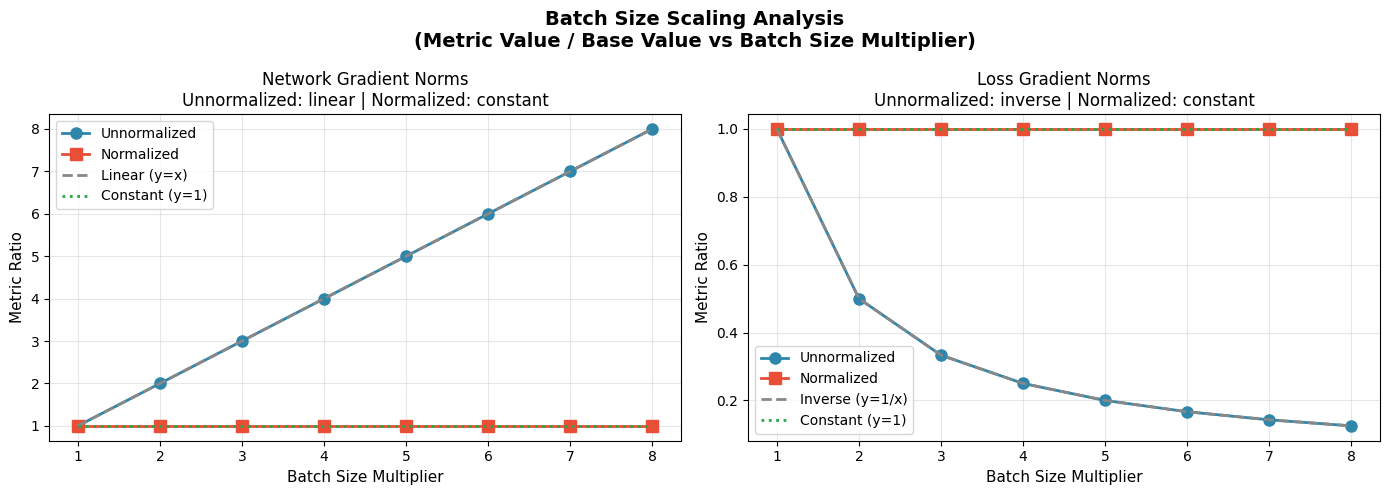

In [22]:
# Run the analysis
results = analyze_batch_size_scaling()

# Print summary table
print_summary(results)

# Generate and save only the ratio plot
fig = plot_scaling_ratios(results)

plt.show()